# Retrieval Augmented Generation with LangGraph

**Project: RegRAG - clause-cited answers on Indian state renewable-energy regulations**

Rishabh Tripathi · Jagath Ponnanna PM · Yashraj Singh Srinet

Net metering limits, banking, wheeling charges and open access rules are set separately by each State
Electricity Regulatory Commission (SERC) and revised through frequent amendments. This notebook builds a RAG
system over SERC regulations for **Gujarat, Maharashtra, Karnataka, Tamil Nadu and Rajasthan** plus central
rules. It follows the structure of the *RAG With LangGraph* class lab, with these additions:
- **Clause-level chunking** with metadata (state, authority, document type, date, draft/final status).
- **Hybrid retrieval**: FAISS (dense) + BM25 (keyword), with a **state filter** and reciprocal-rank fusion.
- **Cross-encoder reranking**.
- An **amendment check** that flags superseded clauses and pulls in the later order.
- **Cited answers** that abstain when the sources don't cover the question.
- A **verify → rewrite → retry** loop in the graph.

## Initial Setup

In [1]:
# !uv pip install langgraph langchain-groq langchain-ollama faiss-cpu pypdf rank-bm25 sentence-transformers

In [2]:
import os, json, re, getpass, warnings, time, urllib.request
import numpy as np
from collections import Counter, defaultdict
from dotenv import load_dotenv
from pathlib import Path
from uuid import uuid4
from IPython.display import display, Markdown

In [3]:
warnings.filterwarnings('ignore')
load_dotenv(override=True)

True

In [4]:
#Check for Groq API Key
import os
import getpass
from dotenv import load_dotenv

load_dotenv(override=True)

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("GROQ API Key: ")

In [5]:
# Project paths (works whether the notebook is run from the project root or from notebooks/)
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
RAW_DIR = ROOT / "data" / "raw"
MANIFEST = json.loads((ROOT / "data" / "manifest.json").read_text(encoding="utf-8"))["documents"]
print(f"{len(MANIFEST)} documents in the manifest, PDFs in {RAW_DIR}")

13 documents in the manifest, PDFs in C:\Users\risha\OneDrive\Desktop\Mini Project\data\raw


## Defining Components

In [6]:
# Question
question = "What is the current net metering capacity limit for rooftop solar in Rajasthan?"

### Chat Model

In [7]:
from langchain.chat_models import init_chat_model

model_name = "openai/gpt-oss-120b"
llm = init_chat_model(model_name, model_provider="groq", temperature=0, max_retries=5)

### Embedding Model

In [8]:
!ollama pull nomic-embed-text # other model can be qwen3-embedding:0.6b

Error: accepts 1 arg(s), received 7


In [9]:
from langchain_ollama import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="nomic-embed-text")

### Vector Store

In [10]:
#Import libraries
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

In [11]:
#To get the dimension of the embedding generated by the model
query_embedding = embeddings_model.embed_query("Hello world!")
len(query_embedding)

768

In [12]:
#Initialize the index (using the basic IndexFlatL2 - exact search; our corpus is small, so accuracy wins over speed)
index = faiss.IndexFlatL2(len(query_embedding))

In [13]:
#Create a vector store
vector_store_faiss = FAISS(
    embedding_function=embeddings_model,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

### Reranker

A cross-encoder reads the question and a chunk **together** and scores their relevance. It's more accurate
than vector similarity, so we use it to re-order the candidates. The first run downloads it (~90 MB).

In [14]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", max_length=512)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 52510.07it/s]

## Indexing

### Loading Documents

Each PDF is described in `data/manifest.json` (state, authority, document type, date, status, and which
earlier document it amends). Missing PDFs are downloaded from their source URLs. One scanned KERC order has no
text layer and is skipped.

In [15]:
from langchain_community.document_loaders import PyPDFLoader

def download_missing_pdfs():
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    for meta in MANIFEST:
        path = RAW_DIR / meta["file"]
        if not path.exists():
            req = urllib.request.Request(meta["source_url"], headers={"User-Agent": "Mozilla/5.0"})
            path.write_bytes(urllib.request.urlopen(req, timeout=90).read())
            print("downloaded", meta["file"])

download_missing_pdfs()

pages_by_doc = {}                        # doc_id -> list of page Documents
for meta in MANIFEST:
    if meta.get("skip"):
        print("skipping", meta["file"], "-", meta["skip_reason"])
        continue
    pages_by_doc[meta["doc_id"]] = PyPDFLoader(str(RAW_DIR / meta["file"])).load()

print(f"Loaded {sum(len(p) for p in pages_by_doc.values())} pages from {len(pages_by_doc)} documents")

Advanced encoding /SymbolSetEncoding not implemented yet


Advanced encoding /SymbolSetEncoding not implemented yet


Advanced encoding /SymbolSetEncoding not implemented yet


Advanced encoding /SymbolSetEncoding not implemented yet


Advanced encoding /SymbolSetEncoding not implemented yet


...

Ignoring wrong pointing object 38 0 (offset 0)


Ignoring wrong pointing object 47 0 (offset 0)


Ignoring wrong pointing object 59 0 (offset 0)


skipping KA_KERC_Order_2023.pdf - Scanned PDF with no extractable text; needs OCR (Tesseract) to include.


Loaded 313 pages from 12 documents


In [16]:
# --- Post-processing: remove page furniture and clean whitespace ---
PAGE_NO = re.compile(r"^\s*(page\s*\d+\s*(of\s*\d+)?|\d{1,3})\s*$", re.I)
TOC = re.compile(r"(\.{5,}|…{2,}|_{5,})")

def clean_pages(pages):
    """Return (page_number, line) pairs with running headers, page numbers and TOC lines removed."""
    page_lines = []
    for i, p in enumerate(pages, start=1):
        text = p.page_content.replace("\t", " ").replace("\u00a0", " ")
        lines = [re.sub(r"\s{2,}", " ", ln).strip() for ln in text.splitlines()]
        page_lines.append((i, [ln for ln in lines if ln]))
    # lines repeated on many pages are running headers/footers
    counts = Counter(ln for _, lines in page_lines for ln in set(lines))
    n = len(page_lines)
    running = {ln for ln, c in counts.items() if n >= 4 and c >= max(3, 0.4 * n)}
    return [(pno, ln) for pno, lines in page_lines for ln in lines
            if ln not in running and not PAGE_NO.match(ln) and not TOC.search(ln)
            and not re.fullmatch(r"[_\-=\s]+", ln)]

cleaned = {doc_id: clean_pages(pages) for doc_id, pages in pages_by_doc.items()}
print({doc_id: len(lines) for doc_id, lines in cleaned.items()})

{'GJ_NM_2016': 1396, 'GJ_NM_CONSOL': 1212, 'GJ_NM_AMD4_2024': 374, 'MH_RRE_2019': 889, 'MH_RRE_AMD1_2023': 1000, 'MH_RRE_AMD2_2024': 655, 'KA_TARIFF_FY24': 918, 'TN_GISS_2021_SUMMARY': 90, 'TN_GISS_2024_DRAFT': 1606, 'RJ_DREGS_2021': 1268, 'RJ_SUOMOTU_2024': 175, 'IN_GEOA_2022': 203}


### Splitting Documents

Regulations are numbered (`6`, `6.2`, `7.3`), so instead of fixed-size chunks we split on **clause
headings**. A numbered line only counts as a heading if the numbering moves forward in small steps, which
filters out table rows and quantities like `1 MW`. In amending documents, quoted clauses stay inside the
paragraph that quotes them. Each sub-clause carries its **section title** in its header, so clause 5.2
still "knows" it belongs to *Capacity limits at Distribution Transformer level*. Bare headings are merged
into the clause that follows. Clauses longer than 1,500 characters are split further with the lab's
`RecursiveCharacterTextSplitter`.

For amending documents we also record **which clauses they change** (a clause reference near a verb like
*substituted* or *increase*). The amendment check uses this later.

In [17]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

HEADING = re.compile(r"^(?P<num>\d{1,2}(?:\.\d{1,2}){0,2})\.?\s+(?P<rest>\S.*)$")
UNIT_WORDS = {"kw", "mw", "kv", "kva", "kwh", "rs", "rs.", "inr", "%", "days", "months", "years", "per", "of", "to", "and", "or"}
REF = re.compile(r"\b(?:[Rr]egulations?|[Cc]lauses?|[Rr]ule)\s+(?:No\.\s*)?(\d{1,2}(?:\.\d{1,2}){0,2})(?![\d])")
AMEND_VERB = re.compile(r"substitut|amend|insert|omit|delet|replac|increas|revis|modif", re.I)
AMENDING_TYPES = {"amendment", "order"}

def is_heading(num, rest, line, last_major, dotted, strict):
    sub = "." in num
    if dotted and not sub and not line.startswith(num + "."):
        return False
    if rest.split()[0].lower().rstrip(",:;") in UNIT_WORDS or not (rest[0].isupper() or rest[0] in "“\"'([‘"):
        return False
    major = int(num.split(".")[0])
    if major == 0 or major > 80:
        return False
    if last_major is None:
        return major <= 3
    if sub:
        return major == last_major if strict else last_major <= major <= last_major + 3
    return last_major < major <= last_major + 2

def split_into_clauses(lines, heading_style="auto", strict=False):
    dotted_count = sum(bool(re.match(r"^\d{1,2}\.\s+[A-Z]", l)) for _, l in lines)
    undotted_count = sum(bool(re.match(r"^\d{1,2}\s+[A-Z]", l)) for _, l in lines)
    dotted = heading_style == "dotted" or (heading_style == "auto" and dotted_count >= 3 and dotted_count >= undotted_count)
    blocks, last_major, titles = [{"clause": "", "section": "", "page": lines[0][0] if lines else 1, "lines": []}], None, {}
    for pno, ln in lines:
        m = HEADING.match(ln)
        if m and is_heading(m["num"], m["rest"], ln, last_major, dotted, strict):
            major = m["num"].split(".")[0]
            last_major = int(major)
            if "." not in m["num"]:                       # top-level heading = the section title
                titles[major] = re.split(r"[.:–-]\s", m["rest"])[0][:90]
            blocks.append({"clause": m["num"], "section": titles.get(major, ""), "page": pno, "lines": [ln]})
        else:
            blocks[-1]["lines"].append(ln)
    blocks = [b for b in blocks if b["lines"]]
    # merge tiny blocks (e.g. a bare section heading) forward into the clause that follows
    merged = []
    for b in blocks:
        if merged and len("\n".join(merged[-1]["lines"])) < 250:
            prev = merged.pop()
            b = {**b, "lines": prev["lines"] + b["lines"], "section": b["section"] or prev["section"]}
        merged.append(b)
    return merged

def amended_refs(text):
    return sorted({m.group(1) for m in REF.finditer(text)
                   if AMEND_VERB.search(text[max(0, m.start() - 120): m.end() + 120])})

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,  # chunk size (characters)
    chunk_overlap=150,  # chunk overlap (characters)
)

all_splits = []
for meta in MANIFEST:
    if meta["doc_id"] not in cleaned:
        continue
    blocks = split_into_clauses(cleaned[meta["doc_id"]], meta.get("heading_style", "auto"),
                                strict=meta["doc_type"] in AMENDING_TYPES)
    for b in blocks:
        for piece in text_splitter.split_text("\n".join(b["lines"])):
            section = f" ({b['section']})" if b["section"] else ""
            header = f"{meta['state']} | {meta['authority']} | {meta['title']} | Clause {b['clause'] or '-'}{section}"
            all_splits.append(Document(
                page_content=f"{header}\n{piece}",            # contextual header helps both retrievers
                metadata={"doc_id": meta["doc_id"], "state": meta["state"], "authority": meta["authority"],
                          "doc_type": meta["doc_type"], "title": meta["title"], "date": meta["date"],
                          "status": meta["status"], "amends": meta.get("amends") or "", "clause": b["clause"],
                          "section": b["section"],
                          "page": b["page"], "text": piece,
                          "refs": amended_refs(piece) if meta.get("amends") else []}))

print(f"Split {len(pages_by_doc)} regulation PDFs into {len(all_splits)} clause-level chunks.")
print(Counter(d.metadata["state"] for d in all_splits))

Split 12 regulation PDFs into 627 clause-level chunks.
Counter({'Maharashtra': 178, 'Tamil Nadu': 141, 'Gujarat': 128, 'Rajasthan': 118, 'Karnataka': 48, 'Central': 14})


In [18]:
# What a chunk looks like: the Rajasthan 2024 order that raised the net-metering limit
sample = next(d for d in all_splits if d.metadata["doc_id"] == "RJ_SUOMOTU_2024" and d.metadata["clause"] == "12")
print(sample.page_content[:600])
print("\nmetadata:", {k: v for k, v in sample.metadata.items() if k != "text"})

Rajasthan | RERC | RERC Suo-Motu Order on net metering capacity under DREGS Regulations, 2021 | Clause 12 (In view of above , the Commission under its power conferred under)
12. In view of above , the Commission under its power conferred under
regulation 19 of the RERC DREGS Regulation 2021 “Power to give
directions”, orders that henceforth net metering arrangement shall be
applicable for loads upto one megawatt (01 MW ) or upto the
sanctioned load /contract demand , whichever is lower, for all
categories of the consumers.
(Dr. Rajesh Sharma) (Hemant Kumar Jain) (Dr. B.N. Sharma)
Member Member

metadata: {'doc_id': 'RJ_SUOMOTU_2024', 'state': 'Rajasthan', 'authority': 'RERC', 'doc_type': 'order', 'title': 'RERC Suo-Motu Order on net metering capacity under DREGS Regulations, 2021', 'date': '2024-02-07', 'status': 'final', 'amends': 'RJ_DREGS_2021', 'clause': '12', 'section': 'In view of above , the Commission under its power conferred under', 'page': 6, 'refs': []}


### Storing in Vector Store

All chunks go into FAISS (dense) and a BM25 index (keyword). BM25 catches exact terms like `500 kW` or
`Regulation 7.3` that embeddings can blur. Embedding takes a few minutes on CPU and seconds on a GPU.

In [19]:
#Add all chunks to vector DB (in batches, with progress). The index is saved to disk, so re-runs skip embedding.
from uuid import NAMESPACE_URL, uuid5

# Deterministic ids (same chunk -> same id on every run) so the cached index lines up with BM25
uuids = [str(uuid5(NAMESPACE_URL, f"{d.metadata['doc_id']}|{d.metadata['clause']}|{i}|{d.metadata['text'][:80]}"))
         for i, d in enumerate(all_splits)]  #Universally unique identifier
for d, uid in zip(all_splits, uuids):
    d.metadata["chunk_id"] = uid

FAISS_DIR = ROOT / "data" / "faiss_index"
REBUILD_INDEX = False

cached = None
if FAISS_DIR.exists() and not REBUILD_INDEX:
    cached = FAISS.load_local(str(FAISS_DIR), embeddings_model, allow_dangerous_deserialization=True)
    if set(cached.index_to_docstore_id.values()) != set(uuids):
        print("Cached index is out of date (chunks changed) - rebuilding.")
        cached = None

if cached is not None:
    vector_store_faiss = cached
    print(f"Loaded cached FAISS index ({vector_store_faiss.index.ntotal} vectors) from {FAISS_DIR}")
else:
    start = time.time()
    for i in range(0, len(all_splits), 64):
        vector_store_faiss.add_documents(documents=all_splits[i:i + 64], ids=uuids[i:i + 64])
        print(f"  embedded {min(i + 64, len(all_splits))}/{len(all_splits)}  ({time.time() - start:.0f}s)")
    vector_store_faiss.save_local(str(FAISS_DIR))
    print("saved index to", FAISS_DIR)

Cached index is out of date (chunks changed) - rebuilding.


  embedded 64/627  (23s)


  embedded 128/627  (50s)


  embedded 192/627  (64s)


  embedded 256/627  (95s)


...

  embedded 384/627  (147s)


  embedded 448/627  (163s)


  embedded 512/627  (184s)


  embedded 576/627  (198s)


  embedded 627/627  (217s)
saved index to C:\Users\risha\OneDrive\Desktop\Mini Project\data\faiss_index


In [20]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(all_splits, k=100)

## Retrieval and Generation with LangGraph

### Define Prompt

In [21]:
#Use Prompt Template
from langchain_core.prompts import ChatPromptTemplate

ABSTAIN = "INSUFFICIENT_CONTEXT"
prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a regulatory analyst assistant for Indian renewable-energy regulations. "
     "Answer ONLY from the numbered sources. Rules:\n"
     "1. Open with the direct answer: Yes or No for a yes/no question, otherwise the figure or limit asked for. "
     "For a comparison, give each state's figure.\n"
     "2. End every factual sentence with its citation, e.g. [S2].\n"
     "3. Copy numbers (kW, MW, %, Rs, dates) exactly as written; name the clause and the order with its date.\n"
     "4. If a source is flagged SUPERSEDED, rely on the later amendment and say the earlier rule changed.\n"
     "5. If a source is flagged DRAFT, say it is a proposal, not law in force.\n"
     "6. Keep states separate; never apply one state's rule to another.\n"
     f"7. If the sources do not answer the question, reply with only: {ABSTAIN}\n"
     "Use at most five sentences."),
    ("human", "Question: {question}\n\nSources:\n{context}\n\nAnswer:"),
])

example_messages = prompt.invoke(
    {"context": "(context goes here)", "question": "(question goes here)"}
).to_messages()

assert len(example_messages) == 2
print(example_messages[0].content, "\n---\n", example_messages[1].content)

You are a regulatory analyst assistant for Indian renewable-energy regulations. Answer ONLY from the numbered sources. Rules:
1. Open with the direct answer: Yes or No for a yes/no question, otherwise the figure or limit asked for. For a comparison, give each state's figure.
2. End every factual sentence with its citation, e.g. [S2].
3. Copy numbers (kW, MW, %, Rs, dates) exactly as written; name the clause and the order with its date.
4. If a source is flagged SUPERSEDED, rely on the later amendment and say the earlier rule changed.
5. If a source is flagged DRAFT, say it is a proposal, not law in force.
6. Keep states separate; never apply one state's rule to another.
7. If the sources do not answer the question, reply with only: INSUFFICIENT_CONTEXT
Use at most five sentences. 
---
 Question: (question goes here)

Sources:
(context goes here)

Answer:


### Retrieval Helpers

- **State detection** maps names, regulators, discoms and cities to a state. Questions only about uncovered states are declined.
- **Hybrid search** runs FAISS and BM25 inside a state filter, then fuses the rankings with reciprocal-rank fusion: `score = Σ 1 / (60 + rank)`.
- **Reranking** keeps the top chunks by cross-encoder score.
- **The amendment check** looks for later documents in the same state that amend a retrieved clause. It flags the older clause and pulls the amendment in.

In [22]:
STATE_ALIASES = {
    "Gujarat": ["gujarat", "gerc", "geda", "dgvcl", "mgvcl", "pgvcl", "ugvcl", "torrent power", "ahmedabad", "surat"],
    "Maharashtra": ["maharashtra", "merc", "msedcl", "mahadiscom", "mumbai", "pune", "nagpur"],
    "Karnataka": ["karnataka", "kerc", "bescom", "mescom", "hescom", "gescom", "bengaluru", "bangalore"],
    "Tamil Nadu": ["tamil nadu", "tamilnadu", "tnerc", "tangedco", "chennai", "coimbatore"],
    "Rajasthan": ["rajasthan", "rerc", "jvvnl", "avvnl", "jdvvnl", "jaipur", "jodhpur"],
}
OTHER_STATES = ["kerala", "punjab", "haryana", "telangana", "andhra pradesh", "uttar pradesh", "madhya pradesh",
                "west bengal", "odisha", "bihar", "delhi", "goa", "assam", "himachal pradesh", "uttarakhand"]
CENTRAL_HINTS = ["central government", "ministry of power", "mop", "mnre", "green energy open access", "open access"]

def detect_states(q):
    q = q.lower()
    return [s for s, aliases in STATE_ALIASES.items() if any(re.search(rf"(?<![a-z]){re.escape(a)}(?![a-z])", q) for a in aliases)]

def uncovered_states(q):
    return [s.title() for s in OTHER_STATES if re.search(rf"\b{s}\b", q.lower())]

def per_state_queries(q, states):
    """One query per state. For a comparison, remove every state name, then add back just one."""
    if len(states) <= 1:
        return {states[0] if states else "ALL": q}
    core = q
    for aliases in STATE_ALIASES.values():
        for a in aliases:
            core = re.sub(rf"(?i)(?<![a-z]){re.escape(a)}(?![a-z])", "", core)
    core = re.sub(r"(?i)\b(in|for|of|between|and|vs\.?|versus)\s*(?=(and|vs|versus)?\s*[?.,]*\s*$)", "", core)
    core = re.sub(r"\s{2,}", " ", core).strip(" ?.,")
    core = re.sub(r"(?i)\s+(in|for|of|and|between)$", "", core)
    core = re.sub(r"(?i)^(compare|contrast)\s+", "What are ", core)
    return {s: f"{core} in {s}?" for s in states}

def hybrid_search(query, allowed_states, k=25):
    in_scope = lambda md: md["state"] in allowed_states
    dense = vector_store_faiss.similarity_search(query, k=k, filter=in_scope, fetch_k=len(all_splits))
    sparse = [d for d in bm25_retriever.invoke(query) if in_scope(d.metadata)][:k]
    fused, by_id = defaultdict(float), {}
    for ranking in (dense, sparse):
        for rank, d in enumerate(ranking):
            fused[d.metadata["chunk_id"]] += 1 / (60 + rank + 1)
            by_id[d.metadata["chunk_id"]] = d
    return [by_id[c] for c in sorted(fused, key=fused.get, reverse=True)]

def rerank(query, docs, top_n=5):
    if not docs:
        return []
    scores = reranker.predict([(query, d.page_content[:2000]) for d in docs], show_progress_bar=False)
    for d, s in zip(docs, scores):
        d.metadata["rerank"] = float(s)
    return sorted(docs, key=lambda d: d.metadata["rerank"], reverse=True)[:top_n]

# doc_id -> ids of documents that amend it (from the manifest)
AMENDED_BY = defaultdict(set)
for meta in MANIFEST:
    if meta.get("amends"):
        AMENDED_BY[meta["amends"]].add(meta["doc_id"])

def refers_to(amending, clause):
    if not clause:
        return False
    if amending.metadata["doc_type"] == "consolidated_regulation":
        return amending.metadata["clause"] == clause
    major = clause.split(".")[0]
    return any(r == clause or r == major or clause.startswith(r + ".") for r in amending.metadata["refs"])

def amendment_check(query, docs):
    """Flag clauses a later final document amends, pull the amendment in, and rank current law first."""
    present = {d.metadata["chunk_id"] for d in docs}
    for d in docs:
        d.metadata["flags"] = []
        if d.metadata["status"] == "draft":
            d.metadata["flags"].append("DRAFT - a proposal, not in force")
    pulled = []
    for d in docs:
        later = [a for a in all_splits
                 if a.metadata["doc_id"] in AMENDED_BY[d.metadata["doc_id"]] and a.metadata["status"] != "draft"
                 and a.metadata["date"] > d.metadata["date"] and refers_to(a, d.metadata["clause"])]
        if later:
            newest = max(later, key=lambda a: a.metadata["date"])
            d.metadata["flags"].append(f"SUPERSEDED - clause {d.metadata['clause']} is amended by "
                                       f"'{newest.metadata['title']}' dated {newest.metadata['date']}")
            missing = [a for a in later if a.metadata["chunk_id"] not in present]
            for a in rerank(query, missing, top_n=1):
                a.metadata["flags"] = [f"AMENDMENT - amends clause {d.metadata['clause']} of '{d.metadata['title']}'"]
                present.add(a.metadata["chunk_id"])
                pulled.append(a)
    # temporal ranking: superseded and draft clauses go after current law
    stale = lambda d: any(f.startswith(("SUPERSEDED", "DRAFT")) for f in d.metadata["flags"])
    return sorted(docs + pulled, key=lambda d: (stale(d), -d.metadata["rerank"]))

def format_sources(docs):
    out = []
    for i, d in enumerate(docs, 1):
        m = d.metadata
        flags = "".join(f"\nFLAG: {f}" for f in m["flags"])
        sec = f" ({m['section']})" if m.get("section") else ""
        out.append(f"[S{i}] {m['state']} | {m['title']} | Clause {m['clause'] or '-'}{sec} | dated {m['date']} | p.{m['page']}"
                   f"{flags}\n{m['text'][:1200]}")
    return "\n\n".join(out)

### Create Graph

The lab's graph is `retrieve → generate`. Ours adds nodes before and after it:

- `classify` detects the state(s) and declines uncovered states straight away.
- `retrieve` runs hybrid search and reranking per state.
- `check_amendments` flags superseded clauses and pulls in later orders.
- `generate` writes a cited answer, or abstains.
- `verify` checks the answer is grounded. If not, `rewrite` rephrases the query and the graph retries once.

In [23]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict
# state class is defined here
class State(TypedDict, total=False):
    question: str
    queries: dict            # one retrieval query per state (may be rewritten)
    states: List[str]
    context: List[Document]
    answer: str
    previous_answer: str
    grounded: bool
    attempts: int

In [24]:
ABSTAIN_SCORE = -6.0   # best cross-encoder score below this -> abstain without calling the LLM
CANT_ANSWER = "I can't answer this from the indexed regulations - the retrieved clauses don't contain the information."

# classification node
def classify(state: State):
    states = detect_states(state["question"])
    other = uncovered_states(state["question"])
    if other and not states:
        return {"states": [], "answer": f"I can't answer this: the indexed regulations cover Gujarat, Maharashtra, "
                                        f"Karnataka, Tamil Nadu, Rajasthan and central rules - not {', '.join(other)}."}
    return {"states": states, "queries": per_state_queries(state["question"], states), "attempts": 0}

# retrieval node: hybrid search + rerank, separately for each state's query
def retrieve(state: State):
    central = ["Central"] if any(h in state["question"].lower() for h in CENTRAL_HINTS) else []
    top_n = 5 if len(state["queries"]) == 1 else 3
    context = []
    for s, q in state["queries"].items():
        scope = list(STATE_ALIASES) + ["Central"] if s == "ALL" else [s] + central
        context += rerank(q, hybrid_search(q, scope)[:30], top_n)
    return {"context": context}

# amendment-check node
def check_amendments(state: State):
    return {"context": amendment_check(state["question"], state["context"])}

# generation node
def generate(state: State):
    docs = state["context"]
    if not docs or max(d.metadata["rerank"] for d in docs) < ABSTAIN_SCORE:
        answer = CANT_ANSWER
    else:
        messages = prompt.invoke({"question": state["question"], "context": format_sources(docs)})
        answer = llm.invoke(messages).content.strip()
        # normalise citation brackets (gpt-oss sometimes writes 【S1】 or adds zero-width spaces)
        answer = re.sub(r"[\u200b-\u200d]", "", answer).replace("【", "[").replace("】", "]")
        if ABSTAIN in answer:
            answer = CANT_ANSWER
    # rollback: a retry that ends in "can't answer" never replaces an earlier answer
    if answer == CANT_ANSWER and state.get("previous_answer"):
        answer = state["previous_answer"]
    return {"answer": answer}

# verification node: is every claim supported by the sources?
def verify(state: State):
    if state["answer"] == CANT_ANSWER:
        # the model declined despite having sources: allow one rewrite-and-retry before accepting it
        return {"grounded": state["attempts"] >= 1}
    check = llm.invoke(
        "Reply with one word, YES or NO. Is every factual claim in the ANSWER supported by the SOURCES?\n\n"
        f"SOURCES:\n{format_sources(state['context'])}\n\nANSWER:\n{state['answer']}").content
    return {"grounded": check.strip().upper().startswith("YES")}

# rewrite node: rephrase the question in regulatory wording and retry once
def rewrite(state: State):
    new_query = llm.invoke(
        "Rewrite this question in the wording of Indian electricity regulations (e.g. net metering, eligible "
        "consumer, sanctioned load, contract demand, banking, wheeling). Keep the state. Output only the question.\n\n"
        + state["question"]).content.strip().splitlines()[0]
    queries = per_state_queries(new_query, state["states"])
    for s in list(queries):
        if s != "ALL" and s.lower() not in queries[s].lower():
            queries[s] += f" in {s}"
    return {"queries": queries, "previous_answer": state["answer"], "attempts": state["attempts"] + 1}

In [25]:
from langgraph.graph import START, StateGraph, END

graph_builder = StateGraph(State)

graph_builder.add_node("classify", classify)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("check_amendments", check_amendments)
graph_builder.add_node("generate", generate)
graph_builder.add_node("verify", verify)
graph_builder.add_node("rewrite", rewrite)

graph_builder.add_edge(START, "classify")
graph_builder.add_conditional_edges("classify", lambda s: "end" if s.get("answer") else "retrieve",
                                    {"end": END, "retrieve": "retrieve"})
graph_builder.add_edge("retrieve", "check_amendments")
graph_builder.add_edge("check_amendments", "generate")
graph_builder.add_edge("generate", "verify")
graph_builder.add_conditional_edges("verify",
                                    lambda s: "rewrite" if not s["grounded"] and s["attempts"] < 1 else "end",
                                    {"rewrite": "rewrite", "end": END})
graph_builder.add_edge("rewrite", "retrieve")

graph = graph_builder.compile()

# # Add memory
# memory = MemorySaver()
# graph = graph_builder.compile(checkpointer=memory)

# config = {"configurable": {"thread_id": "abc123"}}

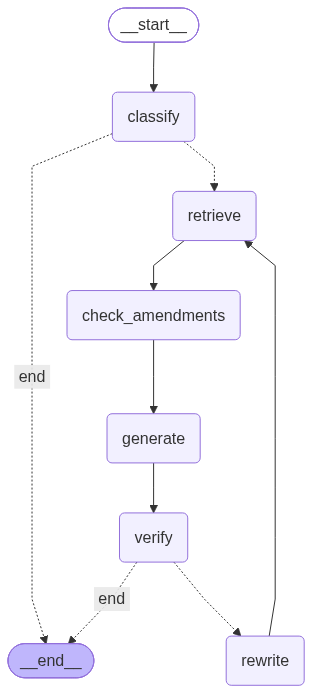

In [26]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))   # rendered via mermaid.ink (needs internet)
except Exception:
    print(graph.get_graph().draw_mermaid())

### Invoke Graph

In [27]:
result = graph.invoke({"question": question})

## ----- To run with memory -----
# result = graph.invoke({"question": question},config)

print("Context:")
for i, d in enumerate(result["context"], 1):
    m = d.metadata
    print(f"  [S{i}] {m['state']} | {m['title'][:70]} | clause {m['clause'] or '-'} | {m['date']} | rerank {m['rerank']:.2f}")
    for f in m["flags"]:
        print(f"        ! {f}")
print(f"\nGrounded: {result['grounded']}  |  retries: {result['attempts']}")
print(f'\nAnswer: {result["answer"]}')

Context:
  [S1] Rajasthan | RERC Suo-Motu Order on net metering capacity under DREGS Regulations,  | clause 9 | 2024-02-07 | rerank 6.74
  [S2] Rajasthan | RERC Suo-Motu Order on net metering capacity under DREGS Regulations,  | clause 10 | 2024-02-07 | rerank 6.09
  [S3] Rajasthan | RERC Suo-Motu Order on net metering capacity under DREGS Regulations,  | clause 2 | 2024-02-07 | rerank 4.03
  [S4] Rajasthan | RERC Suo-Motu Order on net metering capacity under DREGS Regulations,  | clause 11 | 2024-02-07 | rerank 3.56
  [S5] Rajasthan | RERC Suo-Motu Order on net metering capacity under DREGS Regulations,  | clause 12 | 2024-02-07 | rerank 3.27

Grounded: True  |  retries: 0

Answer: 1 MW (One megawatt) is the current net‑metering capacity limit for rooftop solar in Rajasthan [S2][S5].


### More Questions

These test the project's specific behaviours:
- **Amendment handling:** Gujarat's 2016 regulation capped capacity at 50% of sanctioned load; the 2017 amendment exempted residential consumers.
- **A tariff lookup** from the Karnataka order.
- **A two-state comparison.**
- **An out-of-scope state**, which should be declined.

In [28]:
questions = [
    "Is a residential consumer in Gujarat limited to 50% of sanctioned load for rooftop solar?",
    "What is the KERC approved tariff for 1 kW to 10 kW domestic rooftop solar projects for FY24?",
    "Compare the distribution transformer capacity limits for rooftop solar in Gujarat and Maharashtra.",
    "What is the net metering limit for rooftop solar in Kerala?",
]
for q in questions:
    r = graph.invoke({"question": q})
    cites = [f"[S{i}] {d.metadata['doc_id']} cl.{d.metadata['clause'] or '-'} ({d.metadata['date']})"
             for i, d in enumerate(r.get("context", []), 1)]
    display(Markdown(f"**Q: {q}**\n\n{r['answer']}\n\n<small>{' · '.join(cites)}</small>"))

**Q: Is a residential consumer in Gujarat limited to 50% of sanctioned load for rooftop solar?**

No, a residential consumer is not limited to 50 % of its sanctioned load for rooftop solar. The regulation states that for residential consumers the rooftop solar PV system capacity shall be irrespective of their sanctioned load/contract demand, whereas the 50 % cap applies only to non‑residential consumers [S1]. The same exemption is reiterated in Clause 15, confirming that the 50 % limit during the initial two years applies only to consumers other than residential ones, while residential consumers are exempt [S2].

<small>[S1] GJ_NM_CONSOL cl.6.2 (2017-10-06) · [S2] GJ_NM_CONSOL cl.15 (2017-10-06) · [S3] GJ_NM_2016 cl.3.3 (2016-06-18) · [S4] GJ_NM_CONSOL cl.6.1 (2017-10-06) · [S5] GJ_NM_2016 cl.6.2 (2016-06-18)</small>

**Q: What is the KERC approved tariff for 1 kW to 10 kW domestic rooftop solar projects for FY24?**

Rs. 4.50 per unit (without capital subsidy) and Rs. 2.97 per unit (with capital subsidy) are the KERC‑approved tariffs for 1 kW‑to‑10 kW domestic rooftop solar projects for FY 24[S2].

<small>[S1] KA_TARIFF_FY24 cl.3 (2023-06-01) · [S2] KA_TARIFF_FY24 cl.15 (2023-06-01) · [S3] KA_TARIFF_FY24 cl.9 (2023-06-01) · [S4] KA_TARIFF_FY24 cl.15 (2023-06-01) · [S5] KA_TARIFF_FY24 cl.9 (2023-06-01)</small>

**Q: Compare the distribution transformer capacity limits for rooftop solar in Gujarat and Maharashtra.**

Gujarat – under the Fourth Amendment (2024) a rooftop solar system up to 6 kW can be connected without additional system‑strengthening charges; capacity above 6 kW incurs charges to the applicant (S5). Maharashtra – the cumulative rooftop solar capacity on any distribution transformer/feeder must not exceed 70 % of the transformer’s rated capacity, unless a detailed load study permits a higher limit (S3). The earlier Gujarat rule that placed augmentation cost on the consumer was superseded by the 2024 amendment (S7 → S5).

<small>[S1] GJ_NM_CONSOL cl.5.1 (2017-10-06) · [S2] MH_RRE_2019 cl.5.1 (2019-12-30) · [S3] MH_RRE_2019 cl.5.2 (2019-12-30) · [S4] MH_RRE_2019 cl.5.3 (2019-12-30) · [S5] GJ_NM_AMD4_2024 cl.3 (2024-09-04) · [S6] GJ_NM_CONSOL cl.6.2 (2017-10-06) · [S7] GJ_NM_2016 cl.5.1 (2016-06-18) · [S8] GJ_NM_2016 cl.6.2 (2016-06-18)</small>

**Q: What is the net metering limit for rooftop solar in Kerala?**

I can't answer this: the indexed regulations cover Gujarat, Maharashtra, Karnataka, Tamil Nadu, Rajasthan and central rules - not Kerala.

<small></small>

## Conclusion

- **Clause-level chunking with metadata** makes the state filter possible, so answers never mix states.
- **Hybrid search + reranking** finds the right clause; BM25 is strong on exact figures like `500 kW`.
- **The amendment check** keeps answers current: superseded clauses are flagged rather than silently returned, and the later order is pulled in.
- **The graph adds safety around the lab's retrieve → generate core**: out-of-scope questions are declined, answers must cite sources, and an ungrounded answer triggers one rewrite-and-retry.

The full project (Streamlit app, evaluation on 34 hand-written questions with RAGAS, figures) is in this
repository; see `README.md`.